In [2]:
import os
import pandas as pd
import numpy as np
import librosa

In [3]:
import pandas as pd

# path to your CSV file
csv_path = "../data/raw/meta/esc50.csv"

# load dataset
df = pd.read_csv(csv_path)

# view first 5 rows
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [4]:
# check unique categories first
print(df['category'].unique())

<StringArray>
[             'dog',   'chirping_birds',   'vacuum_cleaner',
     'thunderstorm',  'door_wood_knock',      'can_opening',
             'crow',         'clapping',        'fireworks',
         'chainsaw',         'airplane',      'mouse_click',
    'pouring_water',            'train',            'sheep',
      'water_drops',     'church_bells',      'clock_alarm',
  'keyboard_typing',             'wind',        'footsteps',
             'frog',              'cow',   'brushing_teeth',
         'car_horn',   'crackling_fire',       'helicopter',
 'drinking_sipping',             'rain',          'insects',
         'laughing',              'hen',           'engine',
        'breathing',      'crying_baby',         'hand_saw',
         'coughing',   'glass_breaking',          'snoring',
     'toilet_flush',              'pig',  'washing_machine',
       'clock_tick',         'sneezing',          'rooster',
        'sea_waves',            'siren',              'cat',
 'door_woo

In [5]:
# select only required classes
selected_classes = ['dog', 'siren', 'glass_breaking']

filtered_df = df[df['category'].isin(selected_classes)]

# check result
filtered_df['category'].value_counts()

category
dog               40
glass_breaking    40
siren             40
Name: count, dtype: int64

In [6]:
# pick one sample file
sample_row = filtered_df.iloc[0]

file_name = sample_row['filename']

# path to audio file
audio_path = "../data/raw/audio/" + file_name

# load audio
signal, sr = librosa.load(audio_path)

print("Signal shape:", signal.shape)
print("Sample rate:", sr)

Signal shape: (110250,)
Sample rate: 22050


In [7]:
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 216)


In [8]:
mfcc_scaled = np.mean(mfcc.T, axis=0)

print("Final feature vector shape:", mfcc_scaled.shape)

Final feature vector shape: (13,)


In [9]:
X = []
y = []

for index, row in filtered_df.iterrows():
    file_name = row['filename']
    label = row['category']
    
    file_path = "../data/raw/audio/" + file_name
    
    try:
        signal, sr = librosa.load(file_path)
        
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
        mfcc_scaled = np.mean(mfcc.T, axis=0)
        
        X.append(mfcc_scaled)
        y.append(label)
        
    except Exception as e:
        print("Error processing file:", file_name)

In [10]:
print("Total samples:", len(X))
print("Feature vector shape:", X[0].shape)

Total samples: 120
Feature vector shape: (13,)


In [11]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(120, 13)
(120,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (96, 13)
Test shape: (24, 13)


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
y_pred = rf_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.875
Confusion Matrix:
 [[5 1 1]
 [0 7 0]
 [1 0 9]]


In [23]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
y_pred_svm = svm_model.predict(X_test)

In [25]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("SVM Confusion Matrix:\n", cm_svm)

SVM Accuracy: 0.75
SVM Confusion Matrix:
 [[5 1 1]
 [1 6 0]
 [3 0 7]]


In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6666666666666666


In [27]:
import joblib

joblib.dump(rf_model, "../models/audio_model.pkl")

['../models/audio_model.pkl']

In [28]:
# load model
model = joblib.load("../models/audio_model.pkl")

# pick a test file
test_file = "../data/raw/audio/" + filtered_df.iloc[10]['filename']

signal, sr = librosa.load(test_file)
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
mfcc_scaled = np.mean(mfcc.T, axis=0).reshape(1, -1)

prediction = model.predict(mfcc_scaled)

print("Predicted class:", prediction[0])

Predicted class: siren


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/confusion_matrix.png'

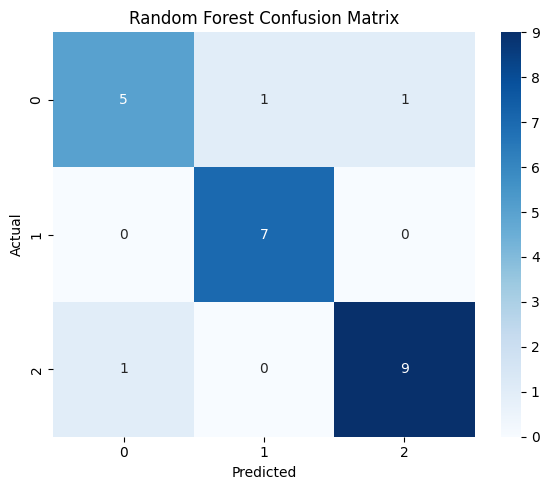

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# recompute confusion matrix (IMPORTANT)
cm = confusion_matrix(y_test, y_pred)

# create new figure
plt.figure(figsize=(6,5))

# plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")


plt.tight_layout()

# save
plt.savefig("../outputs/confusion_matrix.png", dpi=300)

# show
plt.show()